# SoccerNet Frame Extraction Test Pipeline
Downloads a single game at 720p, extracts frames at 1fps, and saves locally.

## Install Dependencies

In [4]:
!pip install SoccerNet opencv-python pandas pyarrow dotenv

import cv2
import pandas as pd
import os
from pathlib import Path
from SoccerNet.Downloader import SoccerNetDownloader
from dotenv import load_dotenv

print('Ready.')

c:\Users\zmsid\Documents\GitHub\BallKnowledge\video_ingestion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready.


## Configuration

In [ ]:
PROJECT_ROOT  = Path('soccernet_project')  # created in current working directory
RAW_VIDEO_DIR = PROJECT_ROOT / 'raw_videos'
FRAMES_DIR    = PROJECT_ROOT / 'frames'
METADATA_PATH = PROJECT_ROOT / 'metadata.parquet'

load_dotenv()
SOCCERNET_PASSWORD = os.getenv('SOCCERNET_PASSWORD')

VIDEO_QUALITY  = '720p'
EVERY_N_FRAMES = 25      # 25fps = 1 frame/sec
JPEG_QUALITY   = 90

# Single test game
TEST_GAME = 'europe_uefa-champions-league/2016-2017/2017-04-18 - 21-45 Real Madrid 4 - 2 Bayern Munich'

for d in [RAW_VIDEO_DIR, FRAMES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT.resolve()}')
print(f'Quality:      {VIDEO_QUALITY}')
print(f'Sampling:     every {EVERY_N_FRAMES} frames = 1 frame/sec')
print(f'Game:         {TEST_GAME}')

Project root: C:\Users\zmsid\Documents\GitHub\BallKnowledge\video_ingestion\soccernet_project
Quality:      720p
Sampling:     every 25 frames = 1 frame/sec
Game:         europe_uefa-champions-league/2016-2017/2017-04-18 - 21-45 Real Madrid 4 - 2 Bayern Munich


## Download Single Test Game

In [7]:
if not SOCCERNET_PASSWORD:
    raise ValueError('Set SOCCERNET_PASSWORD in Cell 2.')

downloader = SoccerNetDownloader(LocalDirectory=str(RAW_VIDEO_DIR))
downloader.password = SOCCERNET_PASSWORD

print(f'Downloading {VIDEO_QUALITY} for: {TEST_GAME}')
downloader.downloadGame(
    files=[f'1_{VIDEO_QUALITY}.mkv', f'2_{VIDEO_QUALITY}.mkv'],
    game=TEST_GAME
)
print('Download complete.')

Download complete.


## Extract Frames

In [8]:
def extract_frames(video_path, game_id, half, out_dir, every_n, quality):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f'Cannot open {video_path}')
        return []

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'  Half {half}: {total} frames at {fps:.1f}fps (~{total/fps/60:.1f} min)')

    save_dir = Path(out_dir) / game_id / f'half{half}'
    save_dir.mkdir(parents=True, exist_ok=True)

    records = []
    raw_idx = saved_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if raw_idx % every_n == 0:
            time_ms = int((raw_idx / fps) * 1000)
            frame_id = f'{game_id}_h{half}_{saved_idx:06d}'
            filepath = save_dir / f'frame_{saved_idx:06d}.jpg'
            cv2.imwrite(str(filepath), frame, [cv2.IMWRITE_JPEG_QUALITY, quality])
            records.append({
                'frame_id':        frame_id,
                'game_id':         game_id,
                'half':            half,
                'frame_num':       saved_idx,
                'time_elapsed_ms': time_ms,
                'file_path':       str(filepath),
            })
            saved_idx += 1
        raw_idx += 1

    cap.release()
    return records


game_id = TEST_GAME.replace('/', '_').replace(' ', '_').replace('-', '_').replace(':', '')
all_records = []

for half in [1, 2]:
    video_path = RAW_VIDEO_DIR / TEST_GAME / f'{half}_{VIDEO_QUALITY}.mkv'
    if not video_path.exists():
        print(f'Half {half} not found at {video_path}')
        continue
    print(f'Processing half {half}...')
    records = extract_frames(video_path, game_id, half, FRAMES_DIR, EVERY_N_FRAMES, JPEG_QUALITY)
    all_records.extend(records)
    print(f'  Saved {len(records)} frames')

print(f'Total frames: {len(all_records)}')

Processing half 1...
  Half 1: 67500 frames at 25.0fps (~45.0 min)
  Saved 2700 frames
Processing half 2...
  Half 2: 67500 frames at 25.0fps (~45.0 min)
  Saved 2700 frames
Total frames: 5400


## Cell 5 — Save Metadata

In [9]:
df = pd.DataFrame(all_records)
df.to_parquet(METADATA_PATH, index=False)
df.to_csv(str(METADATA_PATH).replace('.parquet', '.csv'), index=False)

print(f'Saved {len(df)} rows')
df.head(10)

Saved 5400 rows


,frame_id,game_id,half,frame_num,time_elapsed_ms,file_path
0,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,0,0,soccernet_project\frames\europe_uefa_champions...
1,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,1,1000,soccernet_project\frames\europe_uefa_champions...
2,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,2,2000,soccernet_project\frames\europe_uefa_champions...
3,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,3,3000,soccernet_project\frames\europe_uefa_champions...
4,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,4,4000,soccernet_project\frames\europe_uefa_champions...
5,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,5,5000,soccernet_project\frames\europe_uefa_champions...
6,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,6,6000,soccernet_project\frames\europe_uefa_champions...
7,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,7,7000,soccernet_project\frames\europe_uefa_champions...
8,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,8,8000,soccernet_project\frames\europe_uefa_champions...
9,europe_uefa_champions_league_2016_2017_2017_04...,europe_uefa_champions_league_2016_2017_2017_04...,1,9,9000,soccernet_project\frames\europe_uefa_champions...


## Display Sample Frames
Spot-check that frames look good before scaling up.

Loaded 5400 frames from 1 game(s)


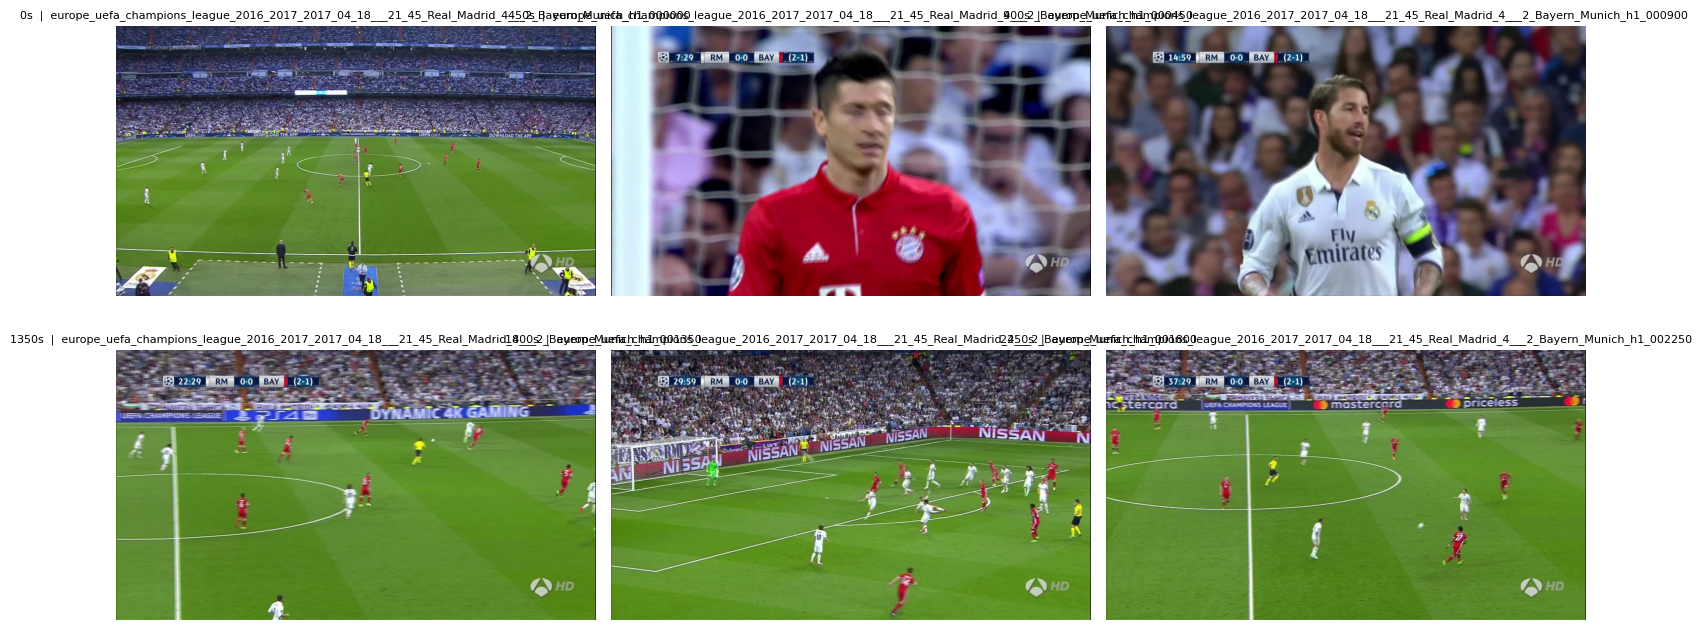

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

df = pd.read_parquet(METADATA_PATH)
print(f'Loaded {len(df)} frames from {df["game_id"].nunique()} game(s)')

half1 = df[df['half'] == 1].reset_index(drop=True)
sample_rows = half1.iloc[::max(1, len(half1)//6)][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img = mpimg.imread(row['file_path'])
    ax.imshow(img)
    ax.set_title(f"{row['time_elapsed_ms']//1000}s  |  {row['frame_id']}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()